In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/thedevastator/the-bards-best-a-character-modeling-dataset/validation.csv
/kaggle/input/datasets/thedevastator/the-bards-best-a-character-modeling-dataset/train.csv
/kaggle/input/datasets/thedevastator/the-bards-best-a-character-modeling-dataset/test.csv


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras 
from keras.models import Sequential
from keras.layers import Embedding,LSTM,Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
train = pd.read_csv('/kaggle/input/datasets/thedevastator/the-bards-best-a-character-modeling-dataset/train.csv')
val = pd.read_csv('/kaggle/input/datasets/thedevastator/the-bards-best-a-character-modeling-dataset/validation.csv')
test = pd.read_csv('/kaggle/input/datasets/thedevastator/the-bards-best-a-character-modeling-dataset/test.csv')

In [4]:
train.head()

,text
0,"First Citizen:\nBefore we proceed any further,..."


In [5]:
val.head()

,text
0,"?\n\nGREMIO:\nGood morrow, neighbour Baptista...."


In [6]:
test.head()

,text
0,rance ta'en\nAs shall with either part's agree...


In [7]:
train_txt = " ".join(train["text"].astype(str))
val_txt = " ".join(val["text"].astype(str))
test_txt = " ".join(test["text"].astype(str))

In [8]:
tokenizer = Tokenizer()

In [9]:
tokenizer.fit_on_texts([train_txt])
vocab = len(tokenizer.word_index) + 1
print(vocab)

11914


In [10]:
list(tokenizer.word_index.items())[:10]

[('the', 1),
 ('and', 2),
 ('to', 3),
 ('i', 4),
 ('of', 5),
 ('my', 6),
 ('you', 7),
 ('a', 8),
 ('that', 9),
 ('in', 10)]

In [11]:
train_sentences = train_txt.split('\n')
val_sentences = val_txt.split('\n')
test_sentences = test_txt.split('\n')

train_sequences = tokenizer.texts_to_sequences(train_sentences)
val_sequences = tokenizer.texts_to_sequences(val_sentences)
test_sequences = tokenizer.texts_to_sequences(test_sentences)

In [12]:
train_sequences[:10]

[[87, 248],
 [143, 34, 962, 145, 609, 127, 16, 106],
 [],
 [35],
 [106, 106],
 [],
 [87, 248],
 [7, 41, 35, 1228, 351, 3, 192, 65, 3, 3678],
 [],
 [35]]

In [13]:
# Train
train_input_sequences = []

for s in train_sequences:
    for i in range(1, len(s)):
        n_gram = s[:i+1]
        train_input_sequences.append(n_gram)


# Validation
val_input_sequences = []

for s in val_sequences:
    for i in range(1, len(s)):
        n_gram = s[:i+1]
        val_input_sequences.append(n_gram)


# Test
test_input_sequences = []

for s in test_sequences:
    for i in range(1, len(s)):
        n_gram = s[:i+1]
        test_input_sequences.append(n_gram)

In [14]:
train_input_sequences[:20]

[[87, 248],
 [143, 34],
 [143, 34, 962],
 [143, 34, 962, 145],
 [143, 34, 962, 145, 609],
 [143, 34, 962, 145, 609, 127],
 [143, 34, 962, 145, 609, 127, 16],
 [143, 34, 962, 145, 609, 127, 16, 106],
 [106, 106],
 [87, 248],
 [7, 41],
 [7, 41, 35],
 [7, 41, 35, 1228],
 [7, 41, 35, 1228, 351],
 [7, 41, 35, 1228, 351, 3],
 [7, 41, 35, 1228, 351, 3, 192],
 [7, 41, 35, 1228, 351, 3, 192, 65],
 [7, 41, 35, 1228, 351, 3, 192, 65, 3],
 [7, 41, 35, 1228, 351, 3, 192, 65, 3, 3678],
 [1228, 1228]]

In [15]:
max_len = np.max([len(x) for x in train_input_sequences])
max_len

np.int64(16)

In [16]:
# applying padding
train_input_sequences = pad_sequences(
    train_input_sequences,
    maxlen=max_len,
    padding='pre'
)

val_input_sequences = pad_sequences(
    val_input_sequences,
    maxlen=max_len,
    padding='pre'
)

test_input_sequences = pad_sequences(
    test_input_sequences,
    maxlen=max_len,
    padding='pre'
)

In [17]:
train_input_sequences[:10]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  87, 248],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 143,  34],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        143,  34, 962],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 143,
         34, 962, 145],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 143,  34,
        962, 145, 609],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 143,  34, 962,
        145, 609, 127],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 143,  34, 962, 145,
        609, 127,  16],
       [  0,   0,   0,   0,   0,   0,   0,   0, 143,  34, 962, 145, 609,
        127,  16, 106],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 106, 106],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  87, 248]], dtype=int32)

In [18]:
# Train
X_train = train_input_sequences[:, :-1]
y_train = train_input_sequences[:, -1]

# Validation
X_val = val_input_sequences[:, :-1]
y_val = val_input_sequences[:, -1]

# Test
X_test = test_input_sequences[:, :-1]
y_test = test_input_sequences[:, -1]

In [19]:
print("Shapes :")
print("X_train",X_train.shape)
print("y_train",y_train.shape)

print("X_val",X_val.shape)
print("y_val",y_val.shape)

print("X_test",X_test.shape)
print("y_test",y_test.shape)

Shapes :
X_train (154531, 15)
y_train (154531,)
X_val (8111, 15)
y_val (8111,)
X_test (7801, 15)
y_test (7801,)


In [20]:
# one hot encoding of targets
y_train = to_categorical(y_train, num_classes=vocab)
y_val = to_categorical(y_val, num_classes=vocab)
y_test = to_categorical(y_test, num_classes=vocab)

In [21]:
y_train[:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [22]:
print("Shapes :")
print("X_train",X_train.shape)
print("y_train",y_train.shape)

print("X_val",X_val.shape)
print("y_val",y_val.shape)

print("X_test",X_test.shape)
print("y_test",y_test.shape)

Shapes :
X_train (154531, 15)
y_train (154531, 11914)
X_val (8111, 15)
y_val (8111, 11914)
X_test (7801, 15)
y_test (7801, 11914)


In [23]:
# building model

model = Sequential()

model.add(Embedding(input_dim=vocab,output_dim=100,input_length =15))
model.add(LSTM(150))
model.add(Dense(vocab,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-08-12 05:05:47.224563: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

In [26]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [27]:
history = model.fit(X_train,y_train,epochs=100,batch_size=128,validation_data=(X_val, y_val),callbacks=early_stop)

Epoch 1/100
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 108s 87ms/step - accuracy: 0.0377 - loss: 6.8618 - val_accuracy: 0.0375 - val_loss: 6.4121
Epoch 2/100
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 88s 73ms/step - accuracy: 0.0666 - loss: 6.3438 - val_accuracy: 0.0778 - val_loss: 6.1297
Epoch 3/100
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 88s 73ms/step - accuracy: 0.0900 - loss: 6.0273 - val_accuracy: 0.0825 - val_loss: 6.0217
Epoch 4/100
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 88s 73ms/step - accuracy: 0.1010 - loss: 5.7938 - val_accuracy: 0.0916 - val_loss: 5.9722
Epoch 5/100
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 88s 73ms/step - accuracy: 0.1085 - loss: 5.5958 - val_accuracy: 0.0921 - val_loss: 5.9669
Epoch 6/100
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 94s 78ms/step - accuracy: 0.1160 - loss: 5.4175 - val_accuracy: 0.0969 - val_loss: 5.9899
Epoch 7/100
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 88s 73ms/step - accuracy: 0.1231 - loss: 5.2514 - val_accuracy: 0.0984 - val_loss: 6.0325
Epoch 8/100
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 96s 79ms/step - accuracy:

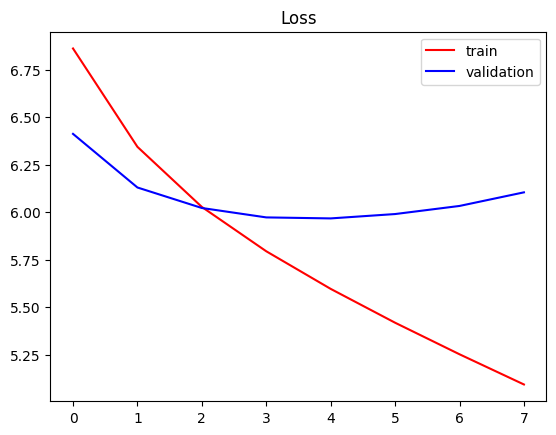

In [30]:
plt.title('Loss')
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

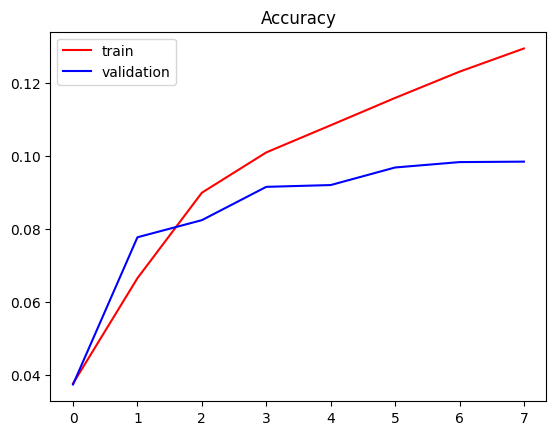

In [31]:
plt.title('Accuracy')
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [29]:
text = "mail"

# tokenize
token_txt = tokenizer.texts_to_sequences([text])[0]
# padding
input_txt = pad_sequences([token_txt],maxlen=15,padding='pre')
# predict
pos = np.argmax(model.predict(input_txt)) # position having highest probablity

for word,index in tokenizer.word_index.items():
    if index == pos:
        print(word)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
vincentio
